In [ ]:
# ON HPC
# srun --pty --nodes=1 --ntasks-per-node=1 --cpus-per-task=4 --mem=320G --account=csd854 -t 48:00:00 -p condo -q condo --wait 0 /bin/bash

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.qvalue.cis_qtl.txt.gz') 
#   - ex: /nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/Endothelial.qvalue.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.tsv')
#   - ex: /nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/Endothelial.cis_qtl_pairs.chr.qvalue.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.sig.tsv')
#   - ex: /nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/Endothelial.cis_qtl_pairs.chr.qvalue.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Bulk')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.qvalue.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        chr.res <- vroom(paste0(indir,'tsv.test/',cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        ct.res <- rbind(ct.res, chr.res)
        gc()
    }
    
    write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.tsv'),
           sep='\t', col.names=T, row.names=F, quote=F)
    write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.sig.tsv'),
               sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
    message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
    
    summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'eQTL.summary.tsv'),
           quote=F, row.names=F, col.names=T, sep='\t')

In [1]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/eQTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<int>,<int>
Endothelial,15439,293,58978117,23747
Hepatocytes,20180,871,77083441,75380
T,7024,21,26833839,3904
HSC,13639,94,52290358,8952
Cholangiocyte,11115,51,42591782,8140
Myeloid,13709,284,52174011,27044
NK,6230,23,23778685,3710
B,6928,7,26698524,653
Bulk,23309,961,89455348,88536


In [3]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [4]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

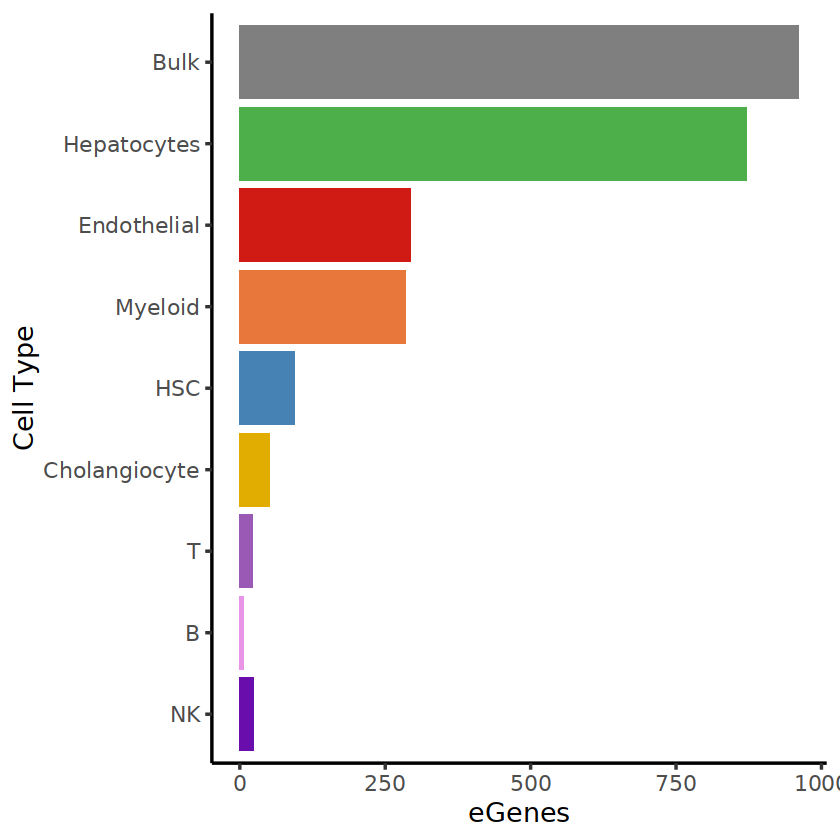

In [5]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='eGenes', y='Cell Type') + theme(legend.position="none")

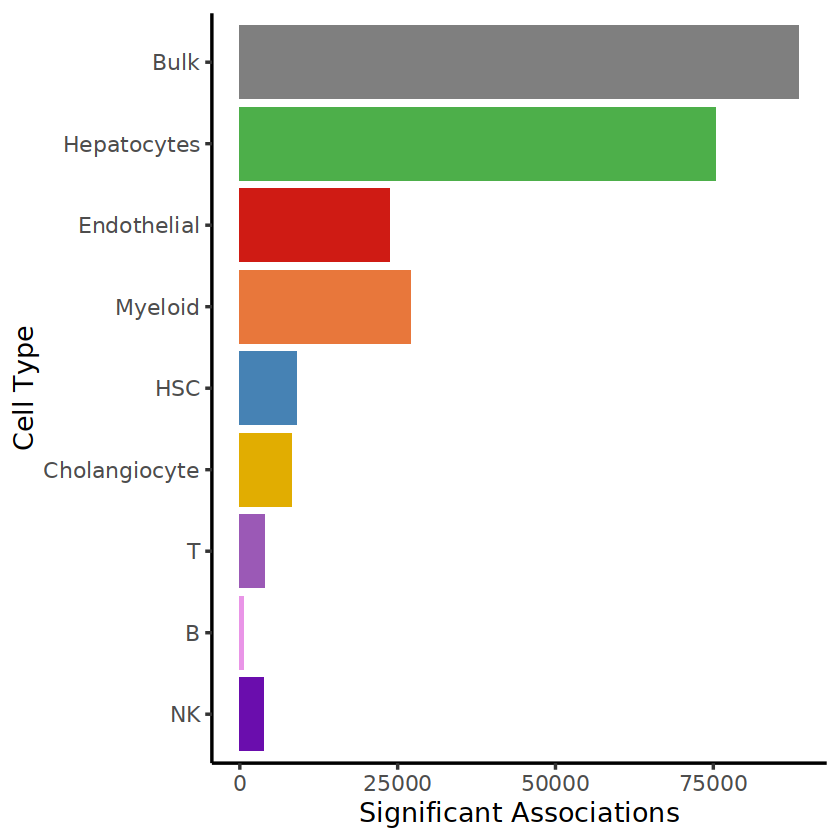

In [7]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")

In [60]:
hep.sumstats <- read.table(paste0(outdir, 'Hepatocytes.cis_qtl_pairs.chr.qvalue.sig.tsv'),
               sep='\t', header=T)

dim(hep.sumstats)
head(hep.sumstats)

[1] 75380    11

,phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,sig.qtl,pval_nominal_threshold
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
1,NOC2L,rs2272757,-13062,0.5290698,62,81,3.496879e-05,-0.3317464,0.07338519,TRUE,4.34229e-05
2,NOC2L,rs70949530,-10138,0.5290698,62,81,2.402730e-05,-0.3255945,0.07031745,TRUE,4.34229e-05
3,NOC2L,rs142545439,6028,0.5348837,61,80,1.092043e-05,-0.3527322,0.07260717,TRUE,4.34229e-05
4,CEP104,rs12134180,-52713,0.2383721,34,41,5.078992e-07,-0.5991046,0.10478528,TRUE,6.89665e-06
5,CEP104,rs12723501,-49788,0.2383721,34,41,5.078992e-07,-0.5991046,0.10478528,TRUE,6.89665e-06
6,CEP104,rs12728640,-48893,0.2383721,34,41,5.078992e-07,-0.5991046,0.10478528,TRUE,6.89665e-06


In [59]:
MVP.credset <- read.table('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.EUR.MVP.2021.credset.hg38.tsv',
                         sep='\t', header=T)

dim(MVP.credset)
head(MVP.credset)

[1] 847  19

,CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,Not.in.Trans.Ethnic,chr.hg38,start.hg38,end.hg38
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>
1,Single SNP,rs2642438,rs2642438,1,220970028,A,G,0.295,-0.079,0.0080,8.04e-23,164197,99.54%,MTARC1,MTARC1,,1,220796685,220796686
2,,rs74816838,rs74816838,1,161643560,T,C,0.112,0.087,0.0128,1.09e-11,164197,96.21%,FCGR2A;FCGR2B,FCGR2A;FCGR2B,*,1,161673769,161673770
3,,rs147998249,rs147998249,8,145732180,C,G,0.003,-2.019,0.1230,7.52e-61,164197,100.00%,GPT,GPT,*,8,144506796,144506797
4,,rs2954038,rs2954038,8,126507389,C,A,0.306,0.139,0.0079,2.12e-70,164197,99.99%,lnc-TRIB1-2;WASHC5,TRIB1,,8,125495146,125495147
5,,rs10883451,rs10883451,10,101924418,C,T,0.477,-0.161,0.0073,3.60e-106,164197,98.90%,ERLIN1,ERLIN1,,10,100164660,100164661
6,,rs11601507,rs11601507,11,5701074,A,C,0.073,0.088,0.0139,2.16e-10,164197,99.82%,TRIM5,TRIM5,,11,5679843,5679844


In [61]:
sum(hep.sumstats$variant_id %in% MVP.credset$CS.SNP)

[1] 34

In [67]:
colnames(MVP.credset)

[1] "CS.Type"               "LEAD.SNP"              "CS.SNP"               
 [4] "Chr"                   "Position"              "EA"                   
 [7] "NEA"                   "EAF"                   "Beta"                 
[10] "SE"                    "P"                     "N"                    
[13] "PP"                    "Nominated.Gene"        "Biological.Prior.Gene"
[16] "Not.in.Trans.Ethnic"   "chr.hg38"              "start.hg38"           
[19] "end.hg38"

In [88]:
filter(hep.sumstats, phenotype_id=='ERLIN1')

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,sig.qtl,pval_nominal_threshold
<chr>,<chr>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
ERLIN1,rs3829161,-120630,0.4476744,61,77,1.739878e-05,-0.4084403,0.08646040,TRUE,2.11454e-05
ERLIN1,rs7906355,-107523,0.3662791,53,63,2.078111e-05,-0.3980136,0.08518128,TRUE,2.11454e-05
ERLIN1,rs12774352,-104830,0.3662791,53,63,2.078111e-05,-0.3980136,0.08518128,TRUE,2.11454e-05
ERLIN1,rs4606421,-103021,0.3372093,50,58,1.532345e-05,-0.4014724,0.08433054,TRUE,2.11454e-05
ERLIN1,rs11593131,-102182,0.3662791,53,63,2.078111e-05,-0.3980136,0.08518128,TRUE,2.11454e-05
ERLIN1,rs11311407,-100677,0.3372093,50,58,1.532345e-05,-0.4014724,0.08433054,TRUE,2.11454e-05
ERLIN1,rs11596076,-100356,0.3662791,53,63,2.078111e-05,-0.3980136,0.08518128,TRUE,2.11454e-05
ERLIN1,rs34236122,-100243,0.3662791,53,63,2.078111e-05,-0.3980136,0.08518128,TRUE,2.11454e-05
ERLIN1,rs7899288,-97346,0.3372093,50,58,1.532345e-05,-0.4014724,0.08433054,TRUE,2.11454e-05


In [121]:
filter(MVP.credset, CS.SNP=='rs10883451')

CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,Not.in.Trans.Ethnic,chr.hg38,start.hg38,end.hg38
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>
,rs10883451,rs10883451,10,101924418,C,T,0.477,-0.161,0.0073,3.6e-106,164197,98.90%,ERLIN1,ERLIN1,,10,100164660,100164661


In [70]:
overlap.data <- inner_join(hep.sumstats, MVP.credset, by = join_by(variant_id==CS.SNP)) %>%
    select(phenotype_id, variant_id, start_distance, pval_nominal, slope, LEAD.SNP, chr.hg38, end.hg38, Beta, SE, P, PP, Nominated.Gene)

In [71]:
overlap.data

phenotype_id,variant_id,start_distance,pval_nominal,slope,LEAD.SNP,chr.hg38,end.hg38,Beta,SE,P,PP,Nominated.Gene
<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
EPHA2,rs11588341,15484,9.513265e-06,-0.3773269,rs1497406,1,16171553,-0.042,0.0075,1.81e-08,16.36%,EPHA2
EPHA2,rs1497407,17041,8.349330e-06,-0.3804022,rs1497406,1,16173110,-0.042,0.0075,2.30e-08,14.08%,EPHA2
EPHA2,rs7538833,21817,1.494710e-06,-0.3871493,rs1497406,1,16177886,-0.039,0.0075,2.13e-07,1.75%,EPHA2
EPHA2,rs1497406,22756,1.063339e-05,-0.3844107,rs1497406,1,16178825,-0.042,0.0074,1.46e-08,21.29%,EPHA2
EPHA2,rs4661718,23344,3.125939e-06,-0.3672506,rs1497406,1,16179413,-0.039,0.0075,1.83e-07,1.63%,EPHA2
EPHA2,rs6679761,23696,1.494710e-06,-0.3871493,rs1497406,1,16179765,-0.039,0.0075,2.31e-07,1.52%,EPHA2
EPHA2,rs4233540,24820,1.857891e-05,-0.3428241,rs1497406,1,16180889,-0.039,0.0075,2.41e-07,1.52%,EPHA2
EPHA2,rs6677710,25054,1.494710e-06,-0.3871493,rs1497406,1,16181123,-0.039,0.0075,2.13e-07,1.87%,EPHA2
EPHA2,rs12057175,25811,1.494710e-06,-0.3871493,rs1497406,1,16181880,-0.039,0.0076,2.45e-07,1.16%,EPHA2


In [129]:
filter(overlap.data, phenotype_id=='CWF19L1')

phenotype_id,variant_id,start_distance,pval_nominal,slope,LEAD.SNP,chr.hg38,end.hg38,Beta,SE,P,PP,Nominated.Gene
<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CWF19L1,rs10883451,-103019,1.835363e-08,0.7162103,rs10883451,10,100164661,-0.161,0.0073,3.6e-106,98.90%,ERLIN1


In [74]:
hep.counts <- read.table('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/Hepatocytes_perdonor.RNA.INT.tsv')

dim(hep.counts)
head(hep.counts)

[1] 20889    86

,HL160042,HL170046,HL190326,HL160029,HL170060,HL210120,HL200925,HL230316,HL220825,HL191025,⋯,HL160026,HL190827,HL150015,HL200529,HL211001,HL210706,HL211025,HL150009,HL201024,HL200212
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AL627309.1,-1.6227112,0.5344601,-1.10897293,-1.2240583,0.60299558,-0.1906023,0.3727933,-1.7426467,1.5224076,-1.5224076,⋯,0.8710608,-1.8946444,-0.2805315,-2.5232398,-0.01457394,-1.3581421,0.3417246,-0.0437342,1.0565923,0.7887938
AL627309.5,-1.4354364,0.7115489,0.34172462,-0.6029956,-0.01457394,1.0565923,0.6383347,0.9144792,1.1645874,0.6744898,⋯,-0.1610005,-1.1089729,-0.3417246,-0.0437342,-0.22037207,-0.8710608,-1.2240583,-0.6383347,1.6227112,0.0437342
LINC01409,-1.4354364,-0.9596939,-1.35814208,-1.0565923,-0.04373420,0.3727933,-0.5683940,-1.8946444,0.2805315,-0.3727933,⋯,0.6029956,-2.5232398,-0.2805315,0.1315391,-0.13153913,1.2240583,1.5224076,1.6227112,-0.6744898,0.4683492
LINC01128,-0.5011308,1.4354364,1.00696106,0.9596939,-0.07293170,0.2203721,1.2240583,-0.4360634,2.5232398,1.1645874,⋯,0.6383347,-0.1610005,-0.9144792,0.3109825,-0.82922563,2.1097056,0.0437342,-0.8710608,-0.2503385,-0.3109825
LINC00115,-1.2240583,-1.7426467,-1.89464435,-1.1645874,-0.13153913,-0.8710608,-1.4354364,-1.2882056,-0.3417246,-1.6227112,⋯,0.6744898,0.1906023,0.1021915,-0.8292256,2.10970561,0.5344601,1.2240583,-0.4042260,-0.2503385,0.7496121
FAM41C,-1.1089729,-0.9596939,-0.01457394,-0.6744898,-1.89464435,1.0565923,-1.6227112,-0.4683492,-1.2240583,0.9144792,⋯,1.0069611,1.5224076,-0.1315391,-1.5224076,0.28053149,0.7115489,1.1089729,0.4683492,-0.1021915,0.4360634


In [98]:
geno.samples <- unlist(read.table(text='HL170044
HL200529
HL230212
1_FNIH-Liver_HL200425_08012023
1_FNIH-Liver_HL220210_08012023
HL220405
HL160017
HL170064
HL220402
2_FNIH-Liver_HL211122_08012023
HL150015
HL181029
HL190114
HL190624
3_FNIH-Liver_HL190114_08012023
HL150009
HL160026
HL160041
HL210207
4_FNIH-Liver_HL201024_08012023
HL211025
HL180809
HL211001
HL230325
5_FNIH-Liver_HL200529_08012023
HL190909
HL160037
HL190214
HL210614
6_FNIH-Liver_HL220405_08012023
HL230324
HL170052
HL170062
HL220210
7_FNIH-Liver_HL230324_08012023
HL170058
HL210521
HL210621
HL220216
HL230316
HL201024
HL160040
HL181031
HL200115
HL160029
HL170055
HL160035
HL170047
HL190215
HL220825
HL190827
HL160030
HL220613
HL221119
HL200805
HL201120
HL210727
HL211106
HL190326
HL170048
HL210706
HL220628
HL160042
HL160022
HL170065
HL200212
14_FNIH-Liver_HL180069_08012023
HL150001
HL220127
HL200707
HL160032
HL191002
HL170046
HL190603
HL200525
HL191025
HL150013
HL200615
HL210726
HL221006
HL221201
HL200925
HL221019
HL230302
HL170049
HL170066
HL180071
HL170060
HL211122
HL221215
HL210806
HL190606
HL191216
HL210120
HL181010'))

In [117]:
snp.geno <- read.table('/nfs/lab/projects/nash_nafld_liver/downstream_all/04_eQTLs/genotypes/rs10883451.tsv', sep='\t')
snp.geno <- snp.geno[10:ncol(snp.geno)]
snp.geno <- stringr::str_split(unlist(snp.geno), ':', simplify=T)[,1]
snp.geno <- stringr::str_split(snp.geno, '\\|', simplify=T)
#snp.geno

snp.geno <- matrix( 
  as.numeric(snp.geno), ncol = 2)
snp.geno <- rowSums(snp.geno)
names(snp.geno) <- geno.samples

snp.geno <- data.frame(genotype=snp.geno, sample=geno.samples)
snp.geno

,genotype,sample
,<dbl>,<chr>
HL170044,1,HL170044
HL200529,0,HL200529
HL230212,0,HL230212
1_FNIH-Liver_HL200425_08012023,1,1_FNIH-Liver_HL200425_08012023
1_FNIH-Liver_HL220210_08012023,0,1_FNIH-Liver_HL220210_08012023
HL220405,1,HL220405
HL160017,1,HL160017
HL170064,0,HL170064
HL220402,1,HL220402


In [ ]:
hep.counts

In [118]:
hep.counts['CWF19L1',]

,HL160042,HL170046,HL190326,HL160029,HL170060,HL210120,HL200925,HL230316,HL220825,HL191025,⋯,HL160026,HL190827,HL150015,HL200529,HL211001,HL210706,HL211025,HL150009,HL201024,HL200212
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CWF19L1,-2.52324,-0.7887938,-0.5344601,-1.894644,-1.742647,0.1610005,-0.7115489,-0.6029956,0.404226,-0.8292256,⋯,-0.4683492,-1.056592,0.2203721,0.01457394,-1.435436,0.1906023,-0.9596939,-1.224058,0.0437342,-1.288206


In [125]:
plot_data

,genotype,sample,counts,genotype.letter
,<dbl>,<chr>,<dbl>,<chr>
HL160042,1,HL160042,-2.5232398,CC
HL170046,1,HL170046,-0.7887938,CC
HL190326,0,HL190326,-0.5344601,CC
HL160029,0,HL160029,-1.8946444,CC
HL170060,0,HL170060,-1.7426467,CC
HL210120,1,HL210120,0.1610005,CC
HL200925,0,HL200925,-0.7115489,CC
HL230316,0,HL230316,-0.6029956,CC
HL220825,0,HL220825,0.4042260,CC


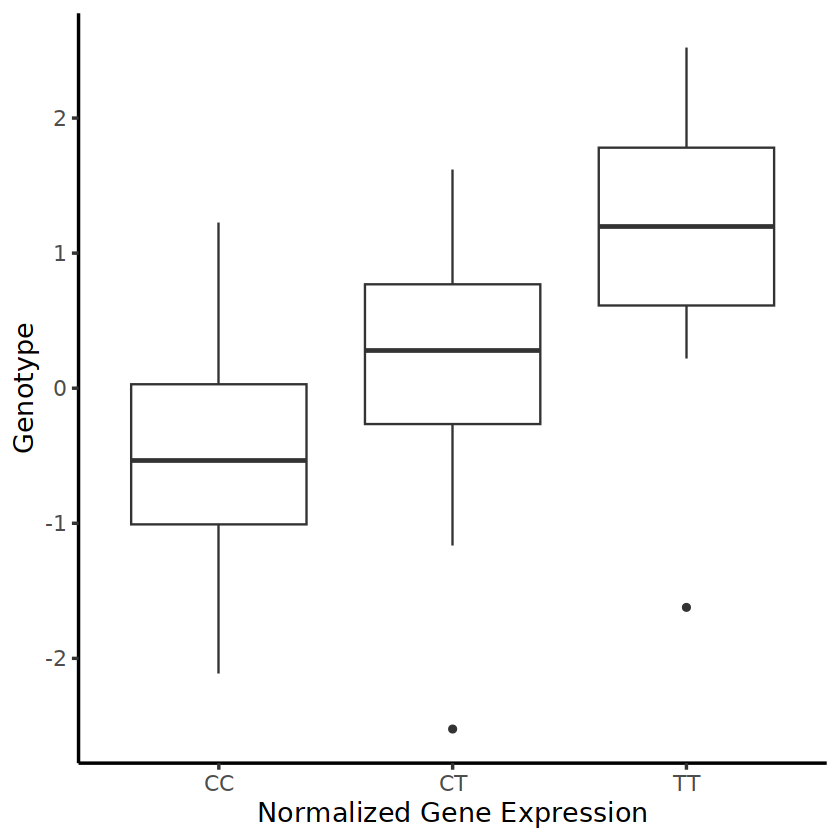

In [128]:
plot_data <- snp.geno[colnames(hep.counts),]
plot_data$counts <- unlist(hep.counts['CWF19L1',])
plot_data$genotype.letter <- 'CC'
plot_data[plot_data$genotype==1,]$genotype.letter <- 'CT'
plot_data[plot_data$genotype==2,]$genotype.letter <- 'TT'
plot_data$genotype.letter <- factor(plot_data$genotype.letter, levels=c('CC','CT','TT'))
#plot_data

ggplot(plot_data, aes(x=genotype.letter, y=counts)) + geom_boxplot() + theme_classic(base_size=16) + 
    labs(x='Normalized Gene Expression', y='Genotype')